<a href="https://colab.research.google.com/github/aiyman14/Sch-Mgmt-661-Applications-of-AI-Models/blob/main/Week6LabPython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing with Gensim

In [1]:
# install gensim
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.0 MB/s eta 0:00:00


In [2]:
from gensim.parsing.preprocessing import STOPWORDS, remove_stopwords
from gensim.parsing.preprocessing import strip_punctuation
from gensim.parsing.preprocessing import stem_text
from gensim.parsing.preprocessing import strip_multiple_whitespaces
from gensim.parsing.preprocessing import strip_numeric, strip_short
from gensim.parsing.preprocessing import preprocess_string, strip_tags
from gensim.models.phrases import Phrases
from gensim.models import LdaModel
from gensim import corpora
from gensim.matutils import corpus2csc

In [3]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
import random
import re

In [4]:
# read in txt file (uploaded directly to Colab)
text_file = open("/content/prideprejudice (1).txt", "r", encoding="utf-8")
prideprej = text_file.readlines()
text_file.close()

In [5]:
prideprej[9]

'It is a truth universally acknowledged, that a single man in possession\n'

In [6]:
# preprocess all at once!
prideprej_lower = [item.lower() for item in prideprej]
CUSTOM_FILTERS = [strip_punctuation, strip_multiple_whitespaces, remove_stopwords, strip_short]
prideprej_toks = [preprocess_string(item, CUSTOM_FILTERS) for item in prideprej_lower]
prideprej_ngrams = Phrases(prideprej_toks, min_count = 3, threshold = 10)
print(prideprej_ngrams[prideprej_toks[9]])

['truth', 'universally', 'acknowledged', 'single', 'man', 'possession']


In [7]:
# prep for wordcloud
separator = ' '
prideprej_long = [separator.join(item) for item in prideprej_ngrams[prideprej_toks]]
prideprej_long = separator.join(prideprej_long)

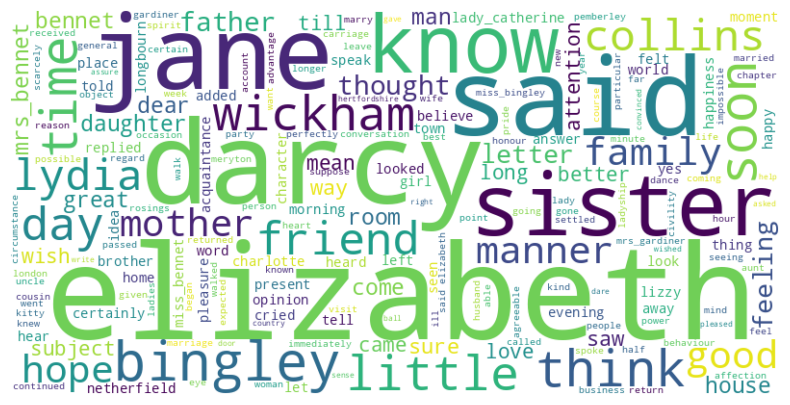

In [8]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200, random_state=2026).generate(prideprej_long)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Working with Document Feature Matrices

In [9]:
# create dictionary
prpr_dict = corpora.Dictionary(prideprej_ngrams[prideprej_toks])
print(prpr_dict.token2id)
# create document feature matrix
prpr_dfm = [prpr_dict.doc2bow(doc) for doc in prideprej_ngrams[prideprej_toks]]
print(prpr_dfm)

{'prejudice': 0, 'pride': 1, 'austen': 2, 'jane': 3, 'chapter': 4, 'acknowledged': 5, 'man': 6, 'possession': 7, 'single': 8, 'truth': 9, 'universally': 10, 'fortune': 11, 'good': 12, 'want': 13, 'wife': 14, 'feelings': 15, 'known': 16, 'little': 17, 'views': 18, 'entering': 19, 'fixed': 20, 'minds': 21, 'neighbourhood': 22, 'considered': 23, 'families': 24, 'property': 25, 'rightful': 26, 'surrounding': 27, 'daughters': 28, 'bennet': 29, 'day': 30, 'dear': 31, 'heard': 32, 'lady': 33, 'said': 34, 'let': 35, 'netherfield': 36, 'park': 37, 'replied': 38, 'mrs_long': 39, 'returned': 40, 'told': 41, 'answer': 42, 'cried': 43, 'impatiently': 44, 'know': 45, 'taken': 46, 'hearing': 47, 'objection': 48, 'tell': 49, 'invitation': 50, 'says': 51, 'came': 52, 'england': 53, 'large_fortune': 54, 'north': 55, 'young_man': 56, 'chaise': 57, 'monday': 58, 'place': 59, 'agreed': 60, 'delighted': 61, 'immediately': 62, 'morris': 63, 'michaelmas': 64, 'servants': 65, 'end': 66, 'house': 67, 'week': 68

In [10]:
# train LDA topic model
lda_model = LdaModel(corpus=prpr_dfm, id2word=prpr_dict, num_topics=10)

In [11]:
# model output
all_topics = lda_model.show_topics(formatted=False, num_topics=-1, num_words=10)

for topic_id, topic_words in all_topics:
    print(f"Topic #{topic_id}: {topic_words}")

Topic #0: [('mother', np.float32(0.020148795)), ('place', np.float32(0.01886619)), ('marriage', np.float32(0.017958311)), ('known', np.float32(0.016662298)), ('feelings', np.float32(0.016625883)), ('elizabeth', np.float32(0.015266621)), ('friend', np.float32(0.013658539)), ('reason', np.float32(0.012366256)), ('minutes', np.float32(0.010429594)), ('took', np.float32(0.010078522))]
Topic #1: [('time', np.float32(0.024737203)), ('heard', np.float32(0.020623626)), ('going', np.float32(0.020140126)), ('house', np.float32(0.016155528)), ('went', np.float32(0.014895143)), ('chapter', np.float32(0.01489287)), ('look', np.float32(0.014391853)), ('able', np.float32(0.0134207895)), ('anxious', np.float32(0.011688522)), ('idea', np.float32(0.011071568))]
Topic #2: [('shall', np.float32(0.021186495)), ('coming', np.float32(0.016597675)), ('better', np.float32(0.013479042)), ('thing', np.float32(0.012771808)), ('seeing', np.float32(0.012323767)), ('rest', np.float32(0.011668399)), ('lydia', np.floa

In [12]:
# feature co-occurence matrix
# convert to sparse matrix
term_doc_mat = corpus2csc(prpr_dfm)

# calculate the word-word co-occurrence matrix
term_term_mat = np.dot(term_doc_mat, term_doc_mat.T)

# convert back to dense numpy array for easier viewing
co_occurrence_matrix = term_term_mat.toarray()

# display fcm
words = list(prpr_dict.token2id.keys())
print(words)
print(co_occurrence_matrix)

['prejudice', 'pride', 'austen', 'jane', 'chapter', 'acknowledged', 'man', 'possession', 'single', 'truth', 'universally', 'fortune', 'good', 'want', 'wife', 'feelings', 'known', 'little', 'views', 'entering', 'fixed', 'minds', 'neighbourhood', 'considered', 'families', 'property', 'rightful', 'surrounding', 'daughters', 'bennet', 'day', 'dear', 'heard', 'lady', 'said', 'let', 'netherfield', 'park', 'replied', 'mrs_long', 'returned', 'told', 'answer', 'cried', 'impatiently', 'know', 'taken', 'hearing', 'objection', 'tell', 'invitation', 'says', 'came', 'england', 'large_fortune', 'north', 'young_man', 'chaise', 'monday', 'place', 'agreed', 'delighted', 'immediately', 'morris', 'michaelmas', 'servants', 'end', 'house', 'week', 'bingley', 'married', 'sure', 'fine', 'girls', 'thing', 'thousand_year', 'affect', 'tiresome', 'marrying', 'thinking', 'design', 'settling', 'likely', 'nonsense', 'talk', 'fall', 'love', 'visit', 'comes', 'soon', 'occasion', 'send', 'better', 'best', 'handsome', '

In [13]:
# randomly sample docs for reading
random.sample(prideprej, 5)

['"Are you pleased with Kent?"\n',
 'assure you, he informed me himself."\n',
 'for she loves to be of use. But tell me, what did you come down to\n',
 "condole with us, and offered her services, or any of her daughters', if\n",
 "point, as well as the still more interesting one of Bingley's being\n"]

In [14]:
# changing unit of analysis
# sentences instead of quasi-sentences
prideprej_split = [re.split('(?<=[.])', qs) for qs in prideprej]
prideprej_split = [item for sublist in prideprej_split for item in sublist]
sentence = ""
prideprej_sents = []
for qs in prideprej_split:
  if qs[len(qs)-1] != ".":
    # not the end of the sentence
    sentence = sentence + qs
  elif qs[len(qs)-1] == ".":
    # end of the sentence
    sentence = sentence + qs
    prideprej_sents.append(sentence)
    sentence = ""

print(len(prideprej))
print(len(prideprej_sents))

13030
6180


In [15]:
prideprej_sents[0:10]

['PRIDE AND PREJUDICE\n\nBy Jane Austen\n\n\n\nChapter 1\n\n\nIt is a truth universally acknowledged, that a single man in possession\nof a good fortune, must be in want of a wife.',
 '\n\nHowever little known the feelings or views of such a man may be on his\nfirst entering a neighbourhood, this truth is so well fixed in the minds\nof the surrounding families, that he is considered the rightful property\nof some one or other of their daughters.',
 '\n\n"My dear Mr.',
 ' Bennet," said his lady to him one day, "have you heard that\nNetherfield Park is let at last?"\n\nMr.',
 ' Bennet replied that he had not.',
 '\n\n"But it is," returned she; "for Mrs.',
 ' Long has just been here, and she\ntold me all about it.',
 '"\n\nMr.',
 ' Bennet made no answer.',
 '\n\n"Do you not want to know who has taken it?" cried his wife impatiently.']

In [16]:
# changing unit of analysis
# chapters instead of quasi-sentences
prideprej_split = [re.split('(?<=Chapter)', qs) for qs in prideprej]
prideprej_split = [item for sublist in prideprej_split for item in sublist]
chapter = ""
prideprej_chaps = []
for qs in prideprej_split:
  if "Chapter" in qs:
    # beginning of the chapter
    prideprej_chaps.append(chapter)
    chapter = ""
    chapter = chapter + qs
  elif "Chapter" not in qs:
    # not the beginning of the chapter
    chapter = chapter + qs

print(len(prideprej))
print(len(prideprej_chaps))

13030
61


In [17]:
print(prideprej_chaps[0])
print(prideprej_chaps[1])
print(prideprej_chaps[2])

PRIDE AND PREJUDICE

By Jane Austen




Chapter 1


It is a truth universally acknowledged, that a single man in possession
of a good fortune, must be in want of a wife.

However little known the feelings or views of such a man may be on his
first entering a neighbourhood, this truth is so well fixed in the minds
of the surrounding families, that he is considered the rightful property
of some one or other of their daughters.

"My dear Mr. Bennet," said his lady to him one day, "have you heard that
Netherfield Park is let at last?"

Mr. Bennet replied that he had not.

"But it is," returned she; "for Mrs. Long has just been here, and she
told me all about it."

Mr. Bennet made no answer.

"Do you not want to know who has taken it?" cried his wife impatiently.

"_You_ want to tell me, and I have no objection to hearing it."

This was invitation enough.

"Why, my dear, you must know, Mrs. Long says that Netherfield is taken
by a young man of large fortune from the north of England; that h